In [59]:
from probjax.nn.helpers import TimeEmbedding 
from probjax.distributions import Normal, Independent
import haiku as hk

import matplotlib.pyplot as plt

import optax
from optax import adam

import jax
import jax.numpy as jnp


def forward(x, t):
    time_emb = TimeEmbedding(dim=128)
    x_concat = jnp.concatenate([x, time_emb(t)], axis=-1)
    return hk.nets.MLP([500, 500, 500, 500, 2])(x_concat)


init, model = hk.without_apply_rng(hk.transform(forward))
params = init(jax.random.PRNGKey(42), jnp.ones((1, 2)), jnp.ones((1, 1)))

In [60]:
# Mixture of Gaussians target distribution
input_dim = 2
p = Independent(Normal(jnp.zeros(input_dim), jnp.ones(input_dim)), 1)
target_samples1 = p.sample(jax.random.PRNGKey(0), (5000,)) + 5.0
target_samples2 = p.sample(jax.random.PRNGKey(1), (5000,)) - 5.0
xs = jnp.concatenate([target_samples1, target_samples2], axis=0)


# Discrete Models i.e. DDPM

>The diffusion process is fixed to a **Markov chain** that gradually adds Gaussian noise to the data according to a **variance schedule** $\beta_1, \beta_2...\beta_T$ where $\beta_1<\beta_2...<\beta_T$

$$
q(x_{1:T} ∣x_0)=\prod_{t=1}^{T} q(x_t∣x_{t−1})
$$
Where we define
$$
q(x_t ∣ x_{t−1})=\mathcal{N}(x_t; \sqrt{1−\beta_t} x_{t−1},\beta_t I)
$$

For training we will need $q(x_t|x_0)$ for all the possible $t$. Which can be shown to be
$$
\alpha_t:=1−β_t
$$

$$
\bar\alpha_t:=\prod_{s=1}^{T} \alpha_s
$$

$$
q(x_t ∣ x_0)=\mathcal{N}(x_t; \sqrt{\bar\alpha_t} x_0,(1−\bar\alpha_t)I)
$$

In [67]:
time_steps = 500

betas = jnp.linspace(0.00001, 0.01, time_steps)


alpha = 1- betas
alpha_bar = jnp.cumprod(alpha)
alpha_bar = jnp.concatenate((jnp.array([1.]), alpha_bar[:-1]), axis=0)
sqrt_alpha_bar = jnp.sqrt(alpha_bar)
one_minus_sqrt_alpha_bar = jnp.sqrt(1 - alpha_bar)


def ddpm_forward(key, x, t):
    noise = jax.random.normal(key, x.shape)
    x_noised = x * jnp.take(sqrt_alpha_bar, t) + noise * jnp.take(one_minus_sqrt_alpha_bar,t)
    return x_noised, noise

def noise_fn(key, x):
    for t in range(time_steps):
        key, subkey = jax.random.split(key)
        x, _ = ddpm_forward(subkey, x, t)
    return x

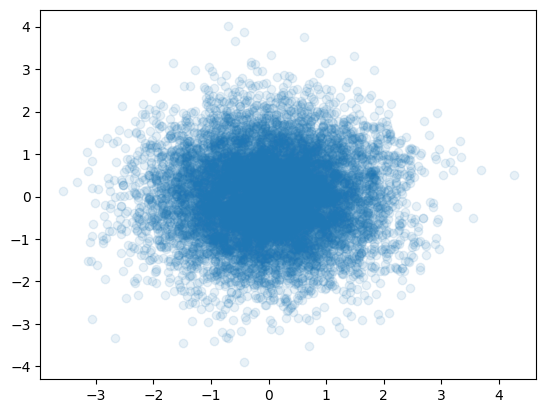

In [69]:
xs_noised = noise_fn(jax.random.PRNGKey(0), xs)

plt.scatter(xs_noised[:, 0], xs_noised[:, 1], alpha=0.1)

The network is trained as following

$$Loss_{simplified}(\theta) = \mathbb{E_{t, x_0, \epsilon}}[||\epsilon - \epsilon_\theta(\sqrt{\bar\alpha_t} x_{0}+ \sqrt{1-\bar\alpha_t}\epsilon,t)||^2] \hspace{0.5cm} \epsilon \in \mathcal{N}(0, I)$$

In [70]:
def loss_fn(params, key,samples, batch_size= 1024):
    rng_time, rng_sample, rng_batch = jax.random.split(key, 3)
    batch_xs = jax.random.choice(rng_batch, samples, shape=(batch_size, ), axis=0)
    times = jax.random.randint(rng_time, (batch_size, 1), 0, time_steps)

    # Forward diffusion
    batch_noisy_xs, batch_noise = ddpm_forward(rng_sample, batch_xs, times)

    # Predict noise
    batch_pred_noise = model(params, batch_noisy_xs, times)

    # Loss
    loss = jnp.mean((batch_noise - batch_pred_noise) ** 2)
    return loss


optimizer = adam(1e-2)
opt_state = optimizer.init(params)

@jax.jit
def step(params, key, opt_state, x):
    loss, g = jax.value_and_grad(loss_fn)(params,key, x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss


In [71]:
key = jax.random.PRNGKey(42)
for i in range(10000):
    key, subkey = jax.random.split(key)
    params, opt_state, loss = step(params, subkey,opt_state, xs)
    if i % 1000 == 0:
        print(loss)

0.998315
0.50823563
0.54053855
0.57123
0.5608894
0.56416947
0.5775636
0.55252695


KeyboardInterrupt: 

Inference is then done by:

<center><img src="https://i.imgur.com/jFkkmXc.png" width=400px></center>

In [1]:
def ddpm_backward(key, x, t):
    alpha_t = jnp.take(alpha, t)
    alpha_t_bar = jnp.take(alpha_bar, t)

    eps_coef = (1 - alpha_t) / (1 - alpha_t_bar) ** .5 
    pred_noise = model(params, x, t) 
    mean = 1 / (alpha_t ** 0.5) * (x - eps_coef * pred_noise)
  
    var = jnp.take(betas, t)
    z = jax.random.normal(key=key, shape=x.shape)

    return mean + (var ** 0.5) * z

In [73]:

def sample_fn(params, key, shape):
    x_T = jax.random.normal(key, shape)

    for t in range(time_steps - 1, 0, -1):
        time = jnp.ones(shape[:-1] + (1,), dtype=int) * t
        x_T = ddpm_backward(key, x_T, time)
    return x_T

In [74]:
samples = sample_fn(params, jax.random.PRNGKey(42), (1000, 2))

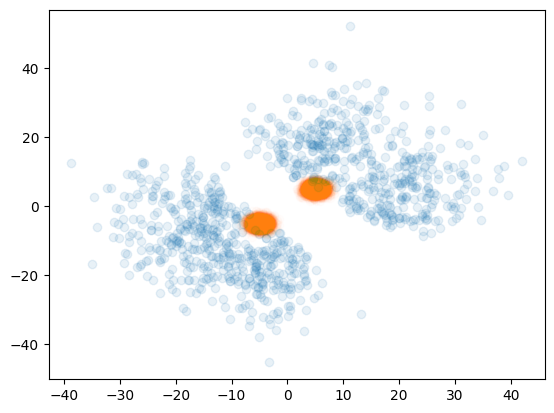

In [76]:
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.1)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.01)


# Continous models i.e. score-based diffusion model

Here the time $t$ is considered to be continous